In [21]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mis_dro.likelihood import cholesky_param_to_covariance
from mis_dro.bayes_conjugates import *
from mis_dro.dataset import portfolio_dataset

In [22]:
dgp = "DowJones"
replication = 0

mmc2_dir = Path("/dcs/pg20/u1508153/datasets/misdro/mmc2")
assert mmc2_dir.exists()
# returns_df = pd.read_excel(mmc2_dir / "Datasets" / dgp / f"{dgp}.xlsx", sheet_name="Assets_Returns", header=None)
data, data_eval = portfolio_dataset(dgp, replication, mmc2_dir)

# portfolio_npl_samples_csv = Path(f"/dcs/large/u1508153/misdro/2025_01_16_mmd_portfolio_samples/b9253bae-05fd-4bbd-91ba-6b398c82a874/npl_sample_{replication}.csv")
portfolio_npl_samples_csv = Path(f"/dcs/large/u1508153/misdro/mmd_portfolio_samples/8c01253f-8d7b-471c-a7b3-3516b2ddef2e/npl_sample_{replication}.csv")

npl_df = pd.read_csv(portfolio_npl_samples_csv, index_col=False, header=None)
npl_samples = npl_df.values

num_posterior_samples = npl_samples.shape[0]
dim = data.shape[1]

In [23]:
# Bayes posterior
posterior = "normal_inverse_wishart"
theta_prior = default_prior_params(posterior, dim=dim)
theta_posterior = get_posterior_params(posterior, data, theta_prior)
mu_post, _, iota_post, Psi_post = theta_posterior

In [24]:
# NPL posterior with full covariance
npl_means = np.zeros((num_posterior_samples, dim))
npl_covs = np.zeros((num_posterior_samples, dim, dim))
for i in range(num_posterior_samples):
    npl_means[i] = npl_samples[i,:dim]
    npl_covs[i] = cholesky_param_to_covariance(dim, npl_samples[i,dim:])
mu_post

array([ 5.68936238e-03,  7.73118061e-03,  1.11847924e-03,  3.71083174e-03,
        1.34338659e-03,  2.54958553e-03, -2.59766966e-03,  1.41061115e-03,
        5.64790217e-03,  4.19930448e-03,  4.58279086e-03,  5.42067970e-04,
        7.31472385e-03,  1.13827276e-03,  2.67061082e-03,  2.84256664e-03,
        3.52467127e-03,  1.03246613e-02,  1.20543412e-02,  1.89853690e-04,
        1.37817885e-03,  5.60736192e-03,  1.98930244e-03, -2.52413681e-04,
        9.25863211e-05,  4.17479341e-04, -4.23404198e-04,  1.65123605e-03])

In [25]:
mean_npl_mean = npl_means.mean(axis=0)
mean_npl_cov = npl_covs.mean(axis=0)
mean_npl_mean

array([-0.00515489,  0.00708536,  0.0022207 ,  0.00777972,  0.00487226,
        0.0243504 , -0.03637194, -0.02410189,  0.01803236,  0.00168076,
       -0.01731151,  0.01376561,  0.02608367,  0.0107471 , -0.01263216,
       -0.00934849,  0.02275244,  0.03597307,  0.04779566,  0.00355925,
        0.01460965,  0.00606126, -0.00358594,  0.00419851, -0.00247341,
        0.00321958, -0.00224728, -0.00759643])

In [26]:
mean_npl_mean - mu_post

array([-0.01084425, -0.00064582,  0.00110222,  0.00406889,  0.00352887,
        0.02180082, -0.03377427, -0.0255125 ,  0.01238445, -0.00251854,
       -0.0218943 ,  0.01322354,  0.01876895,  0.00960882, -0.01530277,
       -0.01219106,  0.01922777,  0.02564841,  0.03574132,  0.0033694 ,
        0.01323147,  0.0004539 , -0.00557524,  0.00445092, -0.002566  ,
        0.0028021 , -0.00182387, -0.00924766])

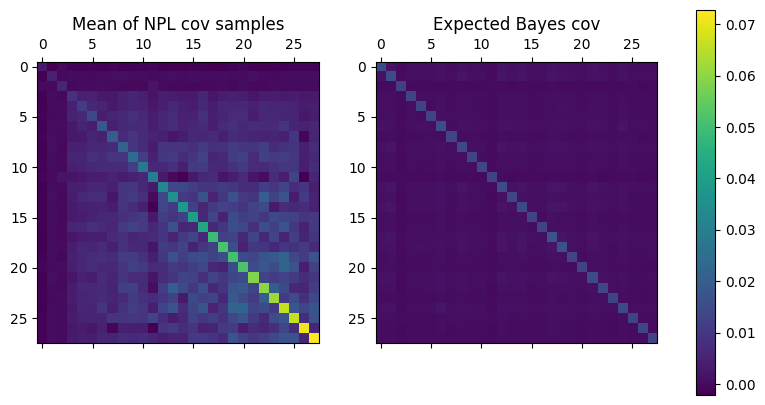

In [27]:
# Create a figure and axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

bayes_cov = (1.0 / float(iota_post)) * Psi_post
vmin = np.min([bayes_cov, mean_npl_cov])
vmax = np.max([bayes_cov, mean_npl_cov])

# Plot the first matrix
c1 = ax1.matshow(mean_npl_cov, cmap='viridis', vmin=vmin, vmax=vmax)
ax1.set_title('Mean of NPL cov samples')

# Plot the second matrix
c2 = ax2.matshow(bayes_cov, cmap='viridis', vmin=vmin, vmax=vmax)
ax2.set_title('Expected Bayes cov')

# Create a shared colorbar
cbar = fig.colorbar(c1, ax=[ax1, ax2], orientation='vertical')

fig.show()


In [28]:
(data[:,0] - data[:,0].mean())/data[:,0].std()

array([-0.07857566,  0.04149057,  0.81622118,  2.39117225, -0.24950012,
       -0.98135984,  0.15891709,  0.85238739, -1.70976965, -0.35504641,
        0.68911413, -0.10021132, -1.09029407,  0.21721846, -0.09773778,
       -0.90914529, -0.09497837,  0.64016825,  0.89965405,  0.7846971 ,
       -0.55424382, -1.69328591,  0.14810352, -1.32036109, -0.04366439,
       -1.49372737,  0.24846637, -0.52848998, -0.75745462, -1.12331963,
       -1.91183844, -0.06447759, -0.94431911, -0.97943259,  1.80609843,
       -0.86258611,  1.66336614,  1.28801141, -0.14306239, -0.03019751,
        0.41695897,  1.36919566, -0.84347801,  1.39348719, -0.57536378,
       -0.10478381,  0.94496377,  1.40515856,  1.01878017,  0.02680839,
        1.62957383, -1.20930824])